# Step 13 — Piecewise-linear (binning) embeddings: is PLR's win about periodicity, or just per-feature nonlinearity?

Step 7 found PLR (periodic embeddings) helped in 9 of 10 dataset x aggregator combinations --
except one: it measurably REGRESSED on YearPredictionMSD's mean-pool arm (8.8293 -> 8.8621,
worse, not noise). That's the one clean counter-example in the project so far, and it raises
a real question: is PLR's usual win about the specific mechanism (learned sin/cos frequencies),
or would ANY per-feature nonlinear treatment do about as well -- in which case periodic's
regression on YE might just be an unlucky frequency-optimization failure, not evidence against
per-feature nonlinearity as an idea.

### The alternative: piecewise-linear encoding ("PLE"), same paper

Instead of learned periodic waves, PLE discretizes each feature into `T` quantile bins (FIXED
edges, fit from training data -- no learned frequencies to optimize) and encodes x as:

    v_t(x) = clip((x - edge[t]) / (edge[t+1] - edge[t]), 0, 1),  t = 0..T-1

1.0 for every bin fully below x, 0.0 for every bin above, and the fractional position within
x's own bin -- then the SAME per-feature Linear -> ReLU tail as PLR. Implemented in
`embeddings.py` as `mode="piecewise_linear"`; self-tested there (bin-edge correctness,
feature-independence, rotation-sensitivity -- see that module's own `__main__`).

### What this notebook does

Compares mean-pool + {none, linear, periodic, piecewise_linear} on YearPredictionMSD (the
dataset that actually regressed) and California Housing (a cheap sanity check with an
established baseline, per notebook 11) -- the exact fixed small-head config from notebook 08,
only the embedding mode varied. Real GPU timing from notebook 08: YE mean-pool ~1.1-1.2
min/run, CA ~0.1 min/run -- 24 runs total (4 modes x 2 datasets x 3 seeds), well under 10
minutes with 3 parallel workers.

## 0. Setup

In [1]:
import os, sys, time, warnings
warnings.filterwarnings("ignore")
PROJECT_DIR = os.getcwd(); sys.path.insert(0, PROJECT_DIR)
os.environ["PYTHONPATH"] = PROJECT_DIR + os.pathsep + os.environ.get("PYTHONPATH", "")

import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt, seaborn as sns
from joblib import Parallel, delayed

from benchmarks_rtdl import BENCHMARKS, load_benchmark, published
from training import get_device
from tuning import run_config
from embeddings import EMBEDDING_MODES

DEVICE = get_device()

# Knobs, overridable from the shell so a headless run needs no edits:
#   SRP_SUBSAMPLE=1500 SRP_SEEDS=1 SRP_EPOCHS=3 SRP_PATIENCE=2 jupyter nbconvert ...
KEYS      = os.environ.get("SRP_KEYS", "YE,CA").split(",")
MODES     = os.environ.get("SRP_MODES", "none,linear,periodic,piecewise_linear").split(",")
SEEDS     = tuple(range(int(os.environ.get("SRP_SEEDS", "3"))))
EPOCHS    = int(os.environ.get("SRP_EPOCHS", "60"))          # matches notebook 08's budget
PATIENCE  = int(os.environ.get("SRP_PATIENCE", "8"))
SUBSAMPLE = int(os.environ.get("SRP_SUBSAMPLE", "0")) or None

THREADS_PER_JOB = 2
N_JOBS = int(os.environ.get("SRP_JOBS", "0")) or (
    3 if DEVICE.type == "cuda" else max(1, min(8, (os.cpu_count() or 2) // THREADS_PER_JOB)))

RUN_DIR = os.path.join(PROJECT_DIR, "runs"); os.makedirs(RUN_DIR, exist_ok=True)
STAMP = time.strftime("%Y%m%d_%H%M%S")
LOG_PATH = os.path.join(RUN_DIR, f"13_progress_{STAMP}.log")
_latest = os.path.join(RUN_DIR, "13_progress.log")
if os.path.islink(_latest) or os.path.exists(_latest):
    os.remove(_latest)
os.symlink(os.path.basename(LOG_PATH), _latest)
def log(msg):
    print(msg, flush=True)
    with open(LOG_PATH, "a") as f: f.write(time.strftime("%H:%M:%S ") + msg + "\n")
def show(df, fmt=None, style=None):
    try:
        s = df.style.format(fmt or {}, na_rep="—"); display(style(s) if style else s)
    except (AttributeError, ImportError):
        display(df.round(4))

sns.set_theme(style="whitegrid", context="notebook")
gpu = torch.cuda.get_device_name(0) if DEVICE.type == "cuda" else "CPU only"
log(f"device: {DEVICE} ({gpu}) | keys={KEYS} modes={MODES} | {N_JOBS} workers | "
    f"seeds={len(SEEDS)} epochs={EPOCHS}")

device: cuda (NVIDIA RTX A4000) | keys=['YE', 'CA'] modes=['none', 'linear', 'periodic', 'piecewise_linear'] | 3 workers | seeds=3 epochs=60


## 1. Data and the fixed config (copied from notebook 08)

In [2]:
DATA, ARRAYS = {}, {}
for k in KEYS:
    d = load_benchmark(k)
    arrays = d.arrays()
    if SUBSAMPLE:
        n = SUBSAMPLE
        arrays = {"Xtr": arrays["Xtr"][:n], "ytr": arrays["ytr"][:n],
                 "Xva": arrays["Xva"][:n // 2], "yva": arrays["yva"][:n // 2],
                 "Xte": arrays["Xte"][:n], "yte": arrays["yte"][:n]}
    DATA[k], ARRAYS[k] = d, arrays
    log(d.summary() + ("  [SUBSAMPLED]" if SUBSAMPLE else ""))

# Small head (head_hidden=embed_dim, head_depth=1 -- PredictionHead's default), matching
# notebook 08's ENS_KW exactly EXCEPT embedding, which is what's varied here.
BASE_PARAMS = dict(num_learners=16, hidden_dim=16, embed_dim=32, depth=1, feature_frac=0.7,
                   dropout=0.1, lr=1e-3, weight_decay=1e-4, head_hidden=32, head_depth=1)

# Extra per-mode keys, matching notebook 08's EMB_KW (d_embedding=8, n_frequencies=16,
# sigma=0.1) where applicable; n_bins=16 chosen to match periodic's n_frequencies for a
# roughly comparable "how much raw information the featurization carries" before the shared
# Linear -> ReLU tail.
MODE_PARAMS = {
    "none": {},
    "linear": {"d_embedding": 8},
    "periodic": {"d_embedding": 8, "n_frequencies": 16, "sigma": 0.1},
    "piecewise_linear": {"d_embedding": 8, "n_bins": 16},
}
print("fixed config (identical across every run; only embedding_mode + its own knobs vary):")
for k, v in BASE_PARAMS.items(): print(f"  {k:16s} {v}")
print("\nper-mode extra params:")
for m in MODES: print(f"  {m:18s} {MODE_PARAMS[m]}")

# Step 7 reference points, transcribed from that notebook's own printed output. The
# regression this notebook exists to investigate: YE mean-pool got WORSE with PLR.
REF = {
    "YE": {"v4 mean-pool (no embedding, notebook 08)": 8.8293,
          "v4 mean-pool + PLR, WIDE head (notebook 08)": 8.8621,
          "our XGBoost (tuned)": 8.8647, "published FT-Transformer": 8.855, "published MLP": 8.853},
    "CA": {"v4 mean-pool (no embedding, notebook 08)": 0.5404,
          "v4 mean-pool + PLR, WIDE head (notebook 08)": 0.5044,
          "our XGBoost (tuned)": 0.4328, "published FT-Transformer": 0.459, "published MLP": 0.499},
}
for k in KEYS:
    print(f"\n{BENCHMARKS[k]['label']} reference points (lower RMSE is better):")
    for name, v in REF.get(k, {}).items(): print(f"  {name:44s} {v:.4f}")

YE YearPredictionMSD  regression features= 90 train=370,972 val=92,743 test=51,630


CA California Housing regression features=  8 train=13,209 val=3,303 test=4,128


fixed config (identical across every run; only embedding_mode + its own knobs vary):
  num_learners     16
  hidden_dim       16
  embed_dim        32
  depth            1
  feature_frac     0.7
  dropout          0.1
  lr               0.001
  weight_decay     0.0001
  head_hidden      32
  head_depth       1

per-mode extra params:
  none               {}
  linear             {'d_embedding': 8}
  periodic           {'d_embedding': 8, 'n_frequencies': 16, 'sigma': 0.1}
  piecewise_linear   {'d_embedding': 8, 'n_bins': 16}

YearPredictionMSD reference points (lower RMSE is better):
  v4 mean-pool (no embedding, notebook 08)     8.8293
  v4 mean-pool + PLR, WIDE head (notebook 08)  8.8621
  our XGBoost (tuned)                          8.8647
  published FT-Transformer                     8.8550
  published MLP                                8.8530

California Housing reference points (lower RMSE is better):
  v4 mean-pool (no embedding, notebook 08)     0.5404
  v4 mean-pool + PLR, WIDE

## 2. The comparison -- 4 embedding modes x 2 datasets

In [3]:
jobs = [(k, m, s) for k in KEYS for m in MODES for s in SEEDS]

t0 = time.time()
def _run(key, mode, seed):
    params = {**BASE_PARAMS, "embedding_mode": mode, **MODE_PARAMS[mode]}
    d = DATA[key]
    r = run_config("meanpool", params, ARRAYS[key], seed, task=d.task, output_dim=d.output_dim,
                   epochs=EPOCHS, patience=PATIENCE, threads=THREADS_PER_JOB)
    r["key"], r["embedding_mode"] = key, mode
    return r

RESULTS = []
for i, r in enumerate(Parallel(n_jobs=N_JOBS, return_as="generator")(
        delayed(_run)(k, m, s) for k, m, s in jobs)):
    RESULTS.append(r)
    log(f"  [{i+1:3d}/{len(jobs)}] {BENCHMARKS[r['key']]['label']:18s} mode={r['embedding_mode']:18s} "
        f"rmse={r['test_rmse']:.4f}  ({r['seconds']/60:.1f} min)  elapsed {(time.time()-t0)/60:.1f} min")
RESULTS = pd.DataFrame(RESULTS)
log(f"all {len(jobs)} runs done in {(time.time()-t0)/60:.1f} min")

/media/homes/latif/SRP/v4/training.py:55: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /__w/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  return {k: torch.as_tensor(np.ascontiguousarray(v)).to(dev) for k, v in arrays.items()}
/media/homes/latif/SRP/v4/training.py:55: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /__w/pytorch/pytorch/

  [  1/24] YearPredictionMSD  mode=none               rmse=0.8028  (1.8 min)  elapsed 1.9 min


  [  2/24] YearPredictionMSD  mode=none               rmse=0.8057  (1.7 min)  elapsed 1.9 min


  [  3/24] YearPredictionMSD  mode=none               rmse=0.8067  (2.1 min)  elapsed 2.2 min


  [  4/24] YearPredictionMSD  mode=linear             rmse=0.8042  (2.1 min)  elapsed 3.9 min


...

  [ 21/24] California Housing mode=periodic           rmse=0.4126  (0.3 min)  elapsed 9.6 min


  [ 22/24] California Housing mode=piecewise_linear   rmse=0.4203  (0.3 min)  elapsed 9.7 min


  [ 23/24] California Housing mode=piecewise_linear   rmse=0.4259  (0.3 min)  elapsed 9.8 min


  [ 24/24] California Housing mode=piecewise_linear   rmse=0.4248  (0.3 min)  elapsed 9.9 min


all 24 runs done in 9.9 min


## 3. RMSE by embedding mode, per dataset

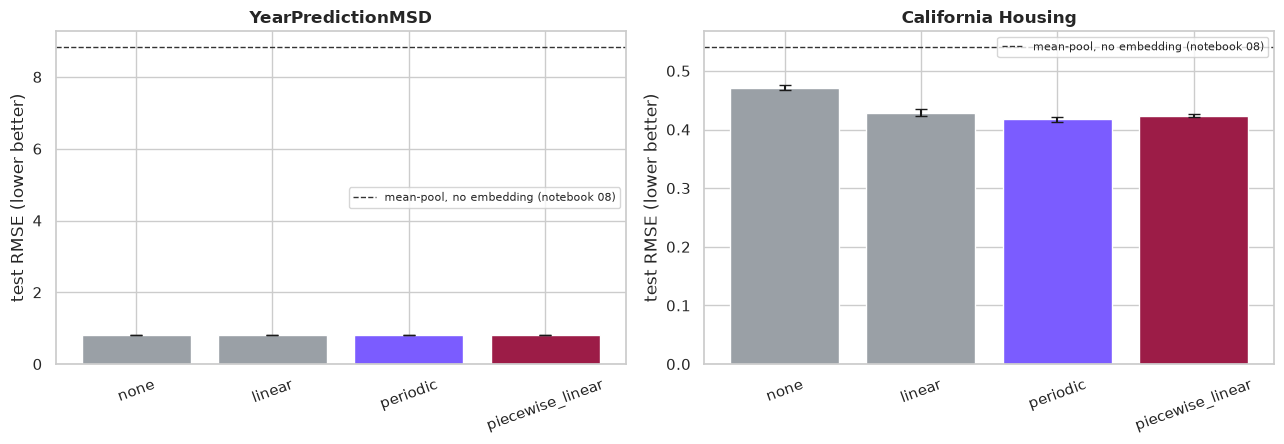


YearPredictionMSD:


,rmse,sd
embedding_mode,,
none,0.8051,0.0020
linear,0.8069,0.0031
periodic,0.8129,0.0009
piecewise_linear,0.8111,0.0050



California Housing:


,rmse,sd
embedding_mode,,
none,0.4715,0.0043
linear,0.4288,0.0056
periodic,0.4176,0.0046
piecewise_linear,0.4237,0.0030


In [4]:
SUMMARY = (RESULTS.groupby(["key", "embedding_mode"])["test_rmse"].agg(["mean", "std"])
          .rename(columns={"mean": "rmse", "std": "sd"}).reset_index())

fig, axes = plt.subplots(1, len(KEYS), figsize=(6.5 * len(KEYS), 4.6))
axes = [axes] if len(KEYS) == 1 else list(axes)
for ax, k in zip(axes, KEYS):
    s = SUMMARY[SUMMARY.key == k].set_index("embedding_mode").reindex(MODES)
    colors = ["#9c1c47" if m == "piecewise_linear" else "#7b5cff" if m == "periodic" else "#9aa0a6" for m in MODES]
    ax.bar(MODES, s["rmse"], yerr=s["sd"].fillna(0.0), color=colors, capsize=4)
    if k in REF:
        ax.axhline(REF[k]["v4 mean-pool (no embedding, notebook 08)"], color="#333", linestyle="--",
                  linewidth=1, label="mean-pool, no embedding (notebook 08)")
        ax.legend(fontsize=8)
    ax.set_ylabel("test RMSE (lower better)")
    ax.set_title(f"{BENCHMARKS[k]['label']}", fontweight="bold")
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.show()

for k in KEYS:
    s = SUMMARY[SUMMARY.key == k].set_index("embedding_mode").reindex(MODES)
    print(f"\n{BENCHMARKS[k]['label']}:")
    show(s[["rmse", "sd"]], {"rmse": "{:.4f}", "sd": "{:.4f}"})

## 4. Findings

*(Computed from the run above.)*

In [5]:
sep = "=" * 92
print(sep); print("FINDINGS -- is PLR's win about periodicity, or just per-feature nonlinearity?"); print(sep)

for k in KEYS:
    s = SUMMARY[SUMMARY.key == k].set_index("embedding_mode").reindex(MODES)
    none_r, none_sd = s.loc["none", "rmse"], (s.loc["none", "sd"] if pd.notna(s.loc["none", "sd"]) else 0.0)
    print(f"\n{BENCHMARKS[k]['label']}:")
    for m in MODES:
        if m == "none":
            continue
        r, sd = s.loc[m, "rmse"], (s.loc[m, "sd"] if pd.notna(s.loc[m, "sd"]) else 0.0)
        delta = r - none_r
        noise = max(sd, none_sd, 1e-9)
        tag = "WORSE than no-embedding" if delta > noise else ("better than no-embedding" if delta < -noise else "within seed noise of no-embedding")
        print(f"   {m:18s} {r:.4f} +/- {sd:.4f}   delta vs none={delta:+.4f}   [{tag}]")

if "YE" in KEYS:
    s = SUMMARY[SUMMARY.key == "YE"].set_index("embedding_mode").reindex(MODES)
    none_r = s.loc["none", "rmse"]
    per_r, per_sd = s.loc["periodic", "rmse"], (s.loc["periodic", "sd"] if pd.notna(s.loc["periodic", "sd"]) else 0.0)
    ple_r, ple_sd = s.loc["piecewise_linear", "rmse"], (s.loc["piecewise_linear", "sd"] if pd.notna(s.loc["piecewise_linear", "sd"]) else 0.0)
    print(f"\nTHE KEY QUESTION -- on YearPredictionMSD, where PLR (periodic) regressed in notebook 08:")
    print(f"   no embedding      : {none_r:.4f}")
    print(f"   periodic (PLR)    : {per_r:.4f} +/- {per_sd:.4f}")
    print(f"   piecewise_linear  : {ple_r:.4f} +/- {ple_sd:.4f}")
    noise = max(per_sd, ple_sd, none_sd, 1e-9)
    # PRIMARY question: does piecewise_linear itself regress below the no-embedding baseline?
    # (Comparing it only to periodic would be misleading -- both could regress together.)
    ple_regresses = ple_r > none_r + noise
    per_regresses = per_r > none_r + noise
    if not ple_regresses and per_regresses:
        print("   -> piecewise_linear does NOT regress here, but periodic DID.")
        print("      Evidence the win is about per-feature nonlinear treatment in general, NOT")
        print("      periodicity specifically -- periodic's YE failure looks like a frequency-")
        print("      optimization issue for THIS dataset, not evidence against the broader idea.")
    elif ple_regresses and per_regresses:
        print("   -> BOTH periodic and piecewise_linear regress vs. no embedding on YE.")
        print("      Evidence YE genuinely doesn't want ANY per-feature nonlinear embedding on")
        print("      mean-pool -- not periodic-specific, a property of this dataset/arm instead.")
    elif ple_regresses and not per_regresses:
        print("   -> piecewise_linear regresses here even though periodic (surprisingly) didn't")
        print("      reproduce its notebook-08 regression at this seed count -- inconclusive,")
        print("      check the per-dataset table above before drawing a conclusion.")
    else:
        print("   -> neither embedding regresses here at this seed count -- inconclusive for")
        print("      isolating periodicity specifically, though piecewise_linear is at least a")
        print("      safe alternative that doesn't hurt.")
print(sep)

FINDINGS -- is PLR's win about periodicity, or just per-feature nonlinearity?

YearPredictionMSD:
   linear             0.8069 +/- 0.0031   delta vs none=+0.0018   [within seed noise of no-embedding]
   periodic           0.8129 +/- 0.0009   delta vs none=+0.0078   [WORSE than no-embedding]
   piecewise_linear   0.8111 +/- 0.0050   delta vs none=+0.0060   [WORSE than no-embedding]

California Housing:
   linear             0.4288 +/- 0.0056   delta vs none=-0.0427   [better than no-embedding]
   periodic           0.4176 +/- 0.0046   delta vs none=-0.0539   [better than no-embedding]
   piecewise_linear   0.4237 +/- 0.0030   delta vs none=-0.0478   [better than no-embedding]

THE KEY QUESTION -- on YearPredictionMSD, where PLR (periodic) regressed in notebook 08:
   no embedding      : 0.8051
   periodic (PLR)    : 0.8129 +/- 0.0009
   piecewise_linear  : 0.8111 +/- 0.0050
   -> BOTH periodic and piecewise_linear regress vs. no embedding on YE.
      Evidence YE genuinely doesn't want 

## 5. Notes / next steps

* Only the mean-pool arm was tested (where the YE regression actually happened). If
  piecewise_linear looks promising, causal attn + piecewise_linear is the natural next check.
* Only YE + California Housing so far. If this clearly resolves the periodicity question,
  extending to Adult/Jannis/Covertype (matching Step 7's full 5-dataset sweep) would confirm
  piecewise_linear is a good DEFAULT, not just a YE-specific fix.
* `n_bins=16` was chosen to roughly match periodic's `n_frequencies=16`, not tuned -- if this
  looks promising, `tuning.py`'s Optuna search space could add `n_bins` as a search dimension
  the same way `n_frequencies`/`sigma` already are for periodic.